<a href="https://colab.research.google.com/github/prakriti459/LAB2ML/blob/main/LAB3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
data= pd.read_csv("Iris.csv")

In [19]:
data.describe()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [9]:

data.shape

(150, 6)

In [10]:
data.columns

Index(['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm',
       'Species'],
      dtype='object')

In [11]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


In [12]:
data.drop("Id", axis=1, inplace= True)

In [13]:
data.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [39]:
numeric_cols = ["SepalLengthCm", "SepalWidthCm", "PetalLengthCm", "PetalWidthCm"]

for col in numeric_cols:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = data[(data[col] < lower_bound) | (data[col] > upper_bound)]

    print(f"{col} Outliers Count:", outliers.shape[0])


SepalLengthCm Outliers Count: 0
SepalWidthCm Outliers Count: 4
PetalLengthCm Outliers Count: 0
PetalWidthCm Outliers Count: 0


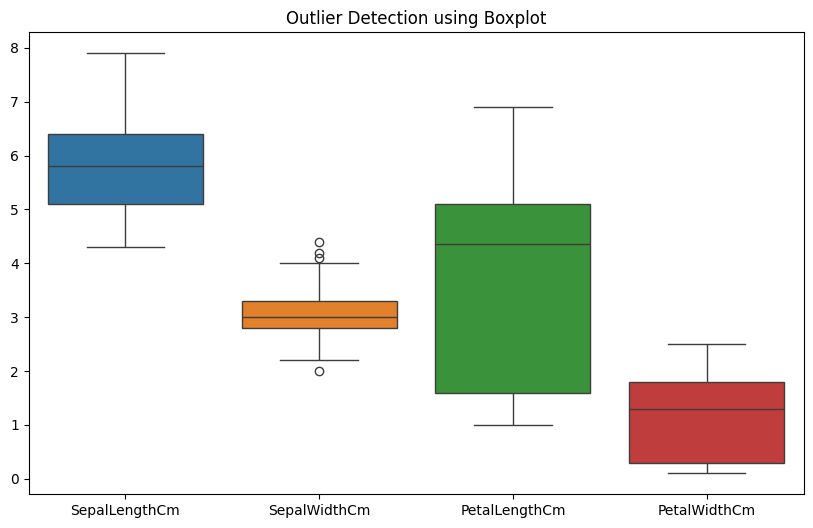

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))
sns.boxplot(data=data[numeric_cols])
plt.title("Outlier Detection using Boxplot")
plt.show()


In [14]:
X = data.drop("Species", axis=1)
y = data["Species"]


In [15]:
from sklearn.preprocessing import LabelEncoder

In [16]:
le= LabelEncoder()
y_encoded= le.fit_transform(y)

In [17]:
y_encoded[:60]


array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

In [18]:
le.classes_

array(['Iris-setosa', 'Iris-versicolor', 'Iris-virginica'], dtype=object)

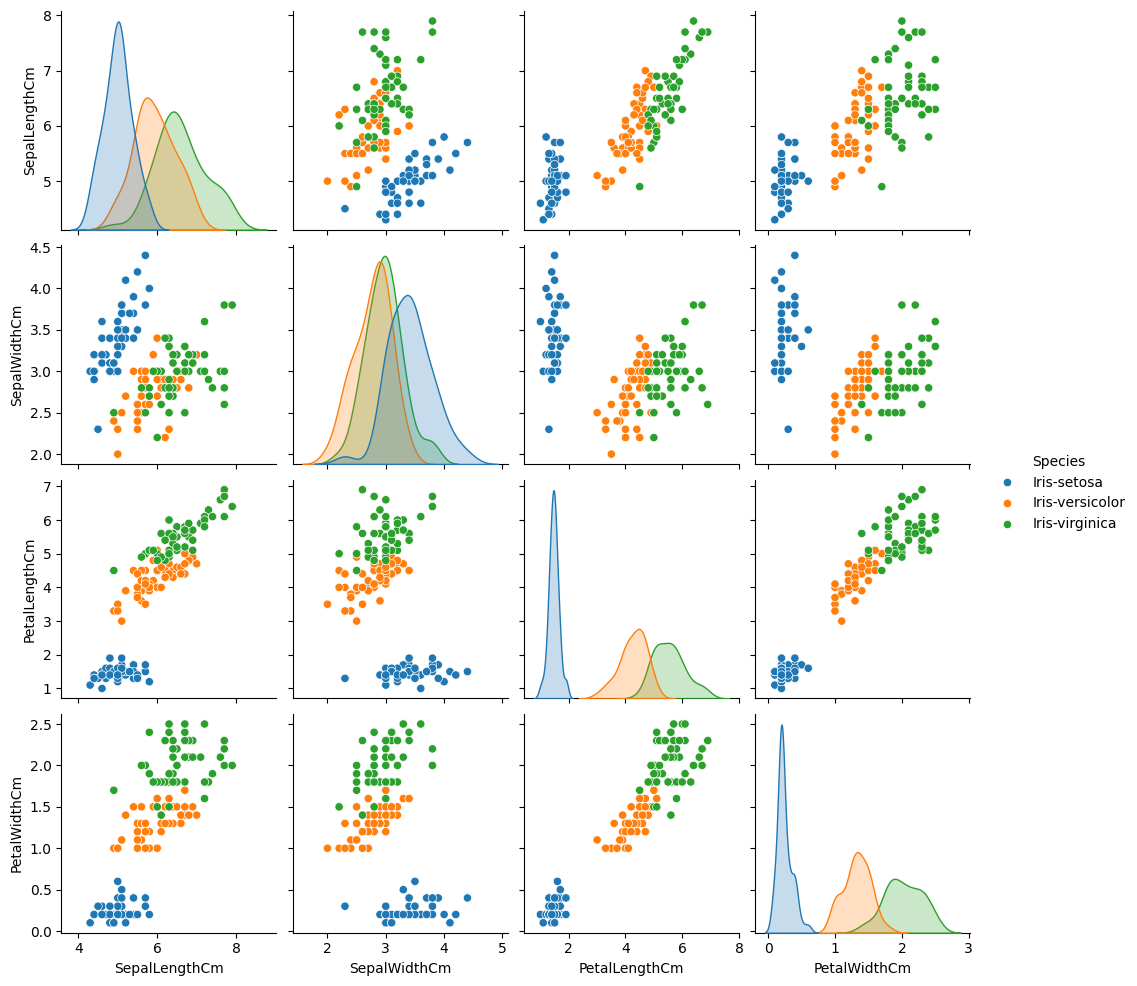

In [20]:

sns.pairplot(data, hue="Species")
plt.show()


In [21]:
corr = data.drop("Species", axis=1).corr()
corr


,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
SepalLengthCm,1.000000,-0.109369,0.871754,0.817954
SepalWidthCm,-0.109369,1.000000,-0.420516,-0.356544
PetalLengthCm,0.871754,-0.420516,1.000000,0.962757
PetalWidthCm,0.817954,-0.356544,0.962757,1.000000


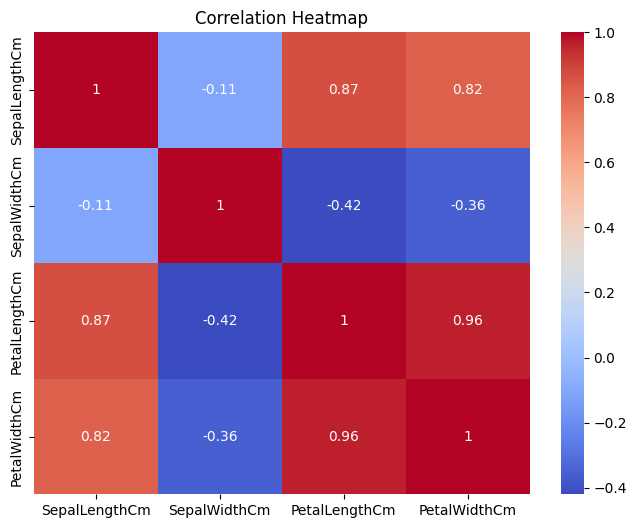

In [22]:
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


In [28]:

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42
)


In [29]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)


(120, 4)
(30, 4)
(120,)
(30,)


In [30]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()


In [31]:
model.fit(X_train, y_train)


LinearRegression()

In [32]:
model.intercept_


np.float64(0.25825051246344954)

In [33]:
model.coef_


array([-0.11368098, -0.06458377,  0.25261442,  0.54938903])

In [34]:
coef_df = pd.DataFrame(model.coef_, X.columns, columns=["Slope"])


In [35]:
y_pred = model.predict(X_test)


In [36]:
sorted_pred = np.sort(y_pred)
cdf = np.arange(1, len(sorted_pred)+1) / len(sorted_pred)


In [37]:
sorted_pred = np.sort(y_pred)
cdf = np.arange(1, len(sorted_pred)+1) / len(sorted_pred)


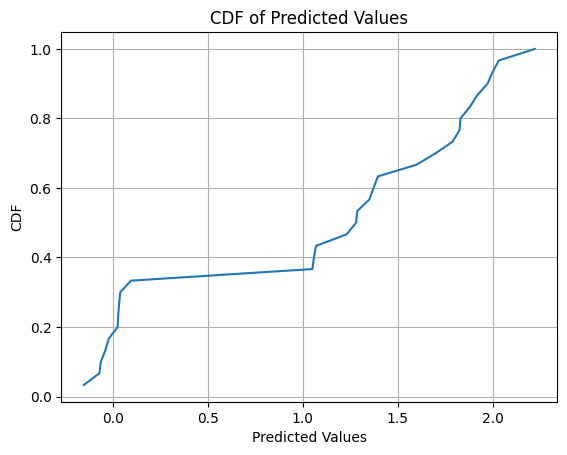

In [38]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(sorted_pred, cdf)
plt.xlabel("Predicted Values")
plt.ylabel("CDF")
plt.title("CDF of Predicted Values")
plt.grid(True)
plt.show()
